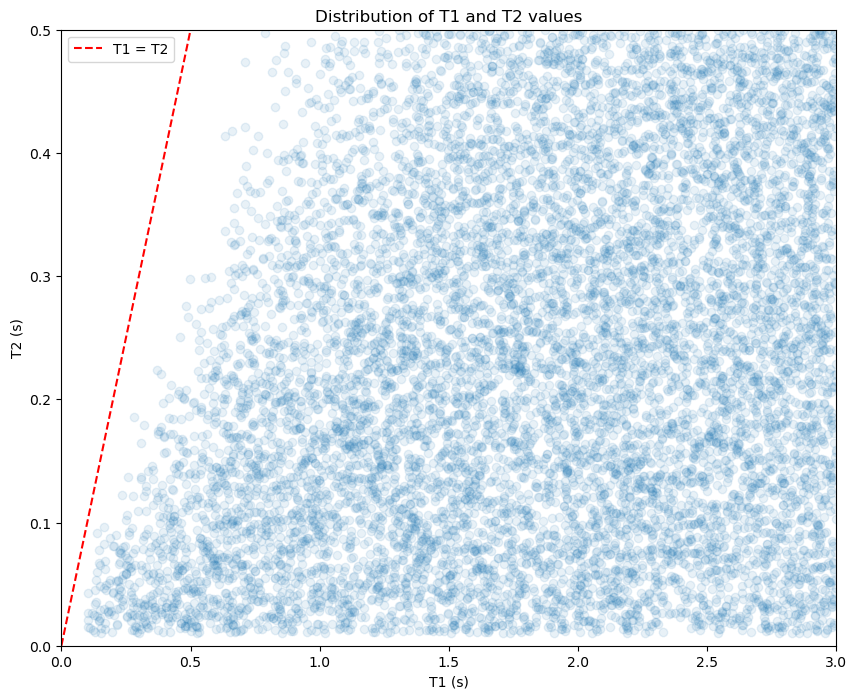

T1 range: 0.101 - 3.000
T2 range: 0.010 - 0.500
Mean T2/T1 ratio: 0.141


In [1]:
import numpy as np

def sample_t1_t2(num_samples):
    T1_samples = []
    T2_samples = []
    
    while len(T1_samples) < num_samples:
        # Propose T1 and T2 values
        T1 = np.random.uniform(0.1, 3.0)  # Range from 100ms to 3000ms
        T2 = np.random.uniform(0.01, 0.5)  # Range from 10ms to 500ms
        
        # Rejection criteria
        if T2 <= T1 and T2 <= 0.7 * T1:
            # Additional probability check to favor certain ratios
            p = np.exp(-((T2/T1 - 0.1) / 0.3)**2)  # Gaussian-like preference for T2/T1 ratio
            
            if np.random.random() < p:
                T1_samples.append(T1)
                T2_samples.append(T2)
    
    return np.array(T1_samples), np.array(T2_samples)

# Usage
num_samples = 10000
T1, T2 = sample_t1_t2(num_samples)

# Visualize the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(T1, T2, alpha=0.1)
plt.plot([0, 3], [0, 3], 'r--', label='T1 = T2')
plt.xlabel('T1 (s)')
plt.ylabel('T2 (s)')
plt.title('Distribution of T1 and T2 values')
plt.legend()
plt.xlim(0, 3)
plt.ylim(0, 0.5)
plt.show()

# Print some statistics
print(f"T1 range: {T1.min():.3f} - {T1.max():.3f}")
print(f"T2 range: {T2.min():.3f} - {T2.max():.3f}")
print(f"Mean T2/T1 ratio: {np.mean(T2/T1):.3f}")


Statistics for Original Method:
T1 range: 0.100 - 3.000
T2 range: 0.010 - 0.500
Mean T2/T1 ratio: 0.256
Median T2/T1 ratio: 0.163
Percentage of samples with T2/T1 > 0.7: 9.23%

Statistics for Rejection Sampling Method:
T1 range: 0.101 - 3.000
T2 range: 0.010 - 0.500
Mean T2/T1 ratio: 0.142
Median T2/T1 ratio: 0.128
Percentage of samples with T2/T1 > 0.7: 0.00%


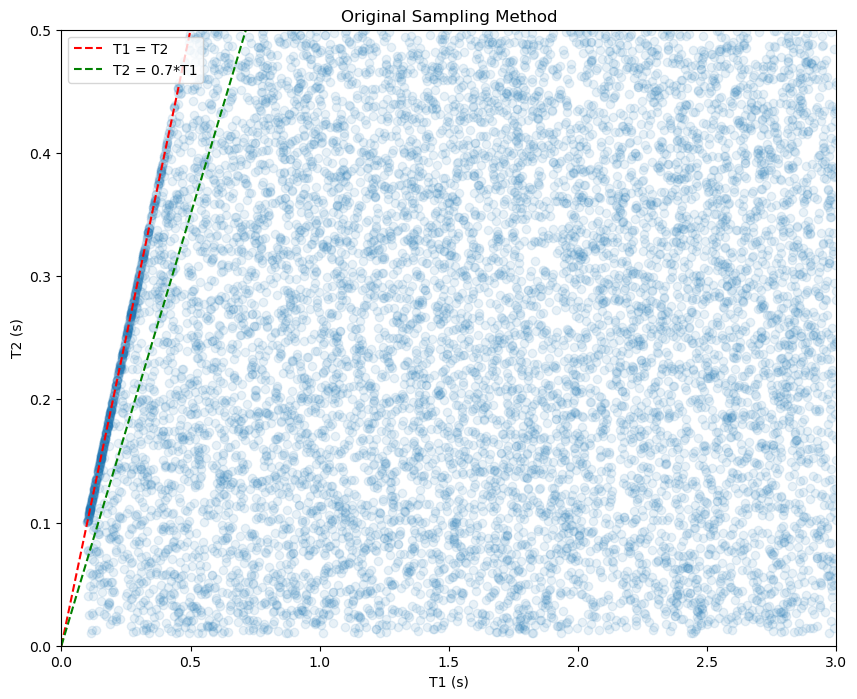

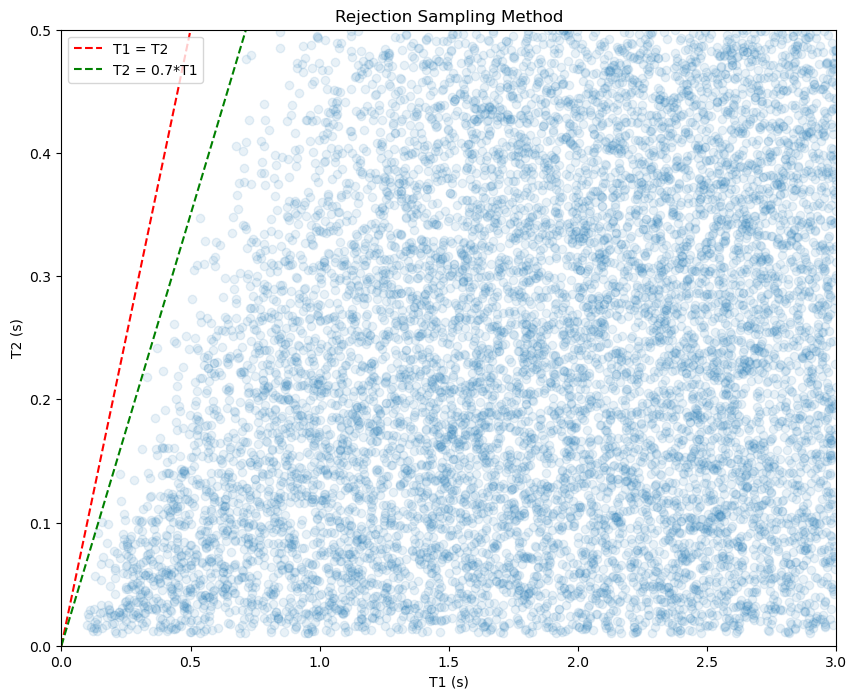

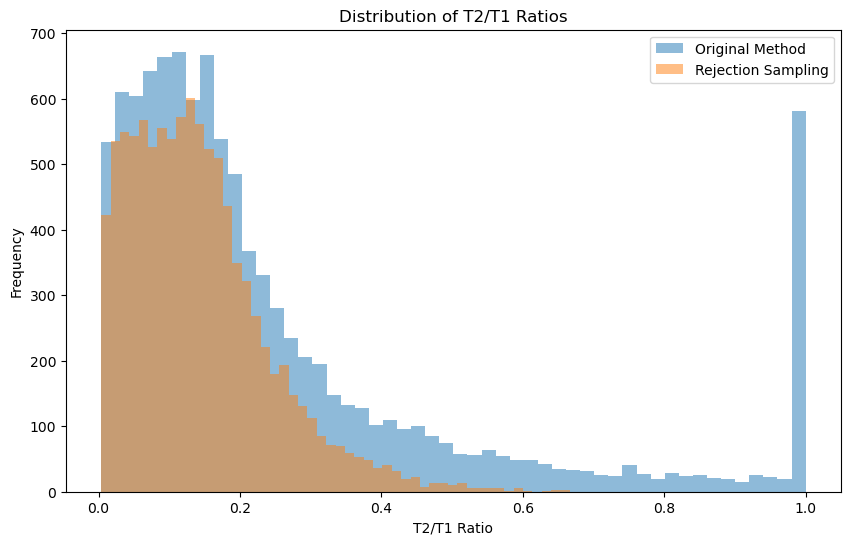

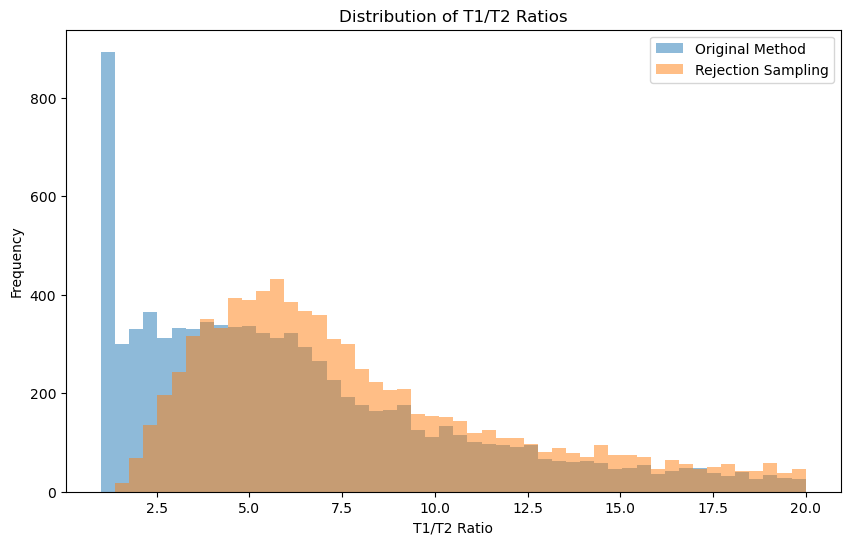

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def original_sample_t1_t2(num_samples):
    T1 = np.random.uniform(0.1, 3.0, num_samples)  # Range from 100ms to 3000ms
    T2 = np.random.uniform(0.01, 0.5, num_samples)  # Range from 10ms to 500ms
    T2 = np.minimum(T2, T1)
    return T1, T2

def rejection_sample_t1_t2(num_samples):
    T1_samples = []
    T2_samples = []
    
    while len(T1_samples) < num_samples:
        T1 = np.random.uniform(0.1, 3.0)
        T2 = np.random.uniform(0.01, 0.5)
        
        if T2 <= T1 and T2 <= 0.7 * T1:
            p = np.exp(-((T2/T1 - 0.1) / 0.3)**2)
            
            if np.random.random() < p:
                T1_samples.append(T1)
                T2_samples.append(T2)
    
    return np.array(T1_samples), np.array(T2_samples)

def plot_distribution(T1, T2, title):
    plt.figure(figsize=(10, 8))
    plt.scatter(T1, T2, alpha=0.1)
    plt.plot([0, 3], [0, 3], 'r--', label='T1 = T2')
    plt.plot([0, 3], [0, 0.7*3], 'g--', label='T2 = 0.7*T1')
    plt.xlabel('T1 (s)')
    plt.ylabel('T2 (s)')
    plt.title(title)
    plt.legend()
    plt.xlim(0, 3)
    plt.ylim(0, 0.5)

def print_statistics(T1, T2, method_name):
    print(f"\nStatistics for {method_name}:")
    print(f"T1 range: {T1.min():.3f} - {T1.max():.3f}")
    print(f"T2 range: {T2.min():.3f} - {T2.max():.3f}")
    print(f"Mean T2/T1 ratio: {np.mean(T2/T1):.3f}")
    print(f"Median T2/T1 ratio: {np.median(T2/T1):.3f}")
    print(f"Percentage of samples with T2/T1 > 0.7: {np.mean(T2/T1 > 0.7)*100:.2f}%")

# Generate samples
num_samples = 10000
T1_original, T2_original = original_sample_t1_t2(num_samples)
T1_rejection, T2_rejection = rejection_sample_t1_t2(num_samples)

# Plot distributions
plot_distribution(T1_original, T2_original, "Original Sampling Method")
plot_distribution(T1_rejection, T2_rejection, "Rejection Sampling Method")

# Print statistics
print_statistics(T1_original, T2_original, "Original Method")
print_statistics(T1_rejection, T2_rejection, "Rejection Sampling Method")

# Plot T2/T1 ratio histograms
plt.figure(figsize=(10, 6))
plt.hist(T2_original/T1_original, bins=50, alpha=0.5, label='Original Method')
plt.hist(T2_rejection/T1_rejection, bins=50, alpha=0.5, label='Rejection Sampling')
plt.xlabel('T2/T1 Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of T2/T1 Ratios')
plt.legend()

# New: Plot T1/T2 ratio histograms
plt.figure(figsize=(10, 6))
plt.hist(T1_original/T2_original, bins=50, range=(1, 20), alpha=0.5, label='Original Method')
plt.hist(T1_rejection/T2_rejection, bins=50, range=(1, 20), alpha=0.5, label='Rejection Sampling')
plt.xlabel('T1/T2 Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of T1/T2 Ratios')
plt.legend()

plt.show()


Statistics for Original Method:
T1 range: 0.100 - 2.000
T2 range: 0.010 - 0.400
Mean T1/T2 ratio: 9.853
Median T1/T2 ratio: 5.080
Percentage of samples with T1/T2 < 1.43: 10.57%

Statistics for Rejection Sampling Method:
T1 range: 0.103 - 2.000
T2 range: 0.010 - 0.400
Mean T1/T2 ratio: 12.634
Median T1/T2 ratio: 6.992
Percentage of samples with T1/T2 < 1.43: 0.00%


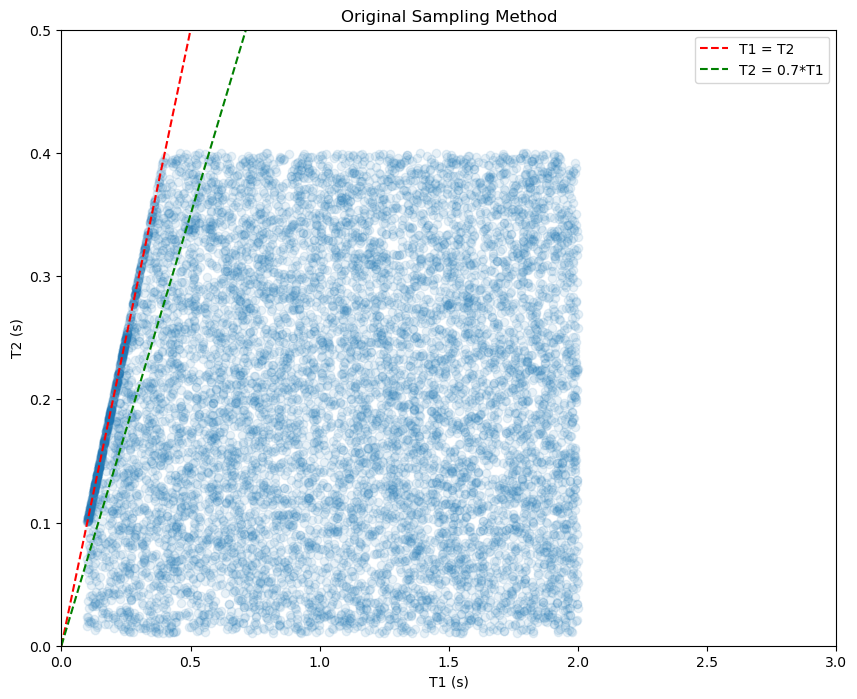

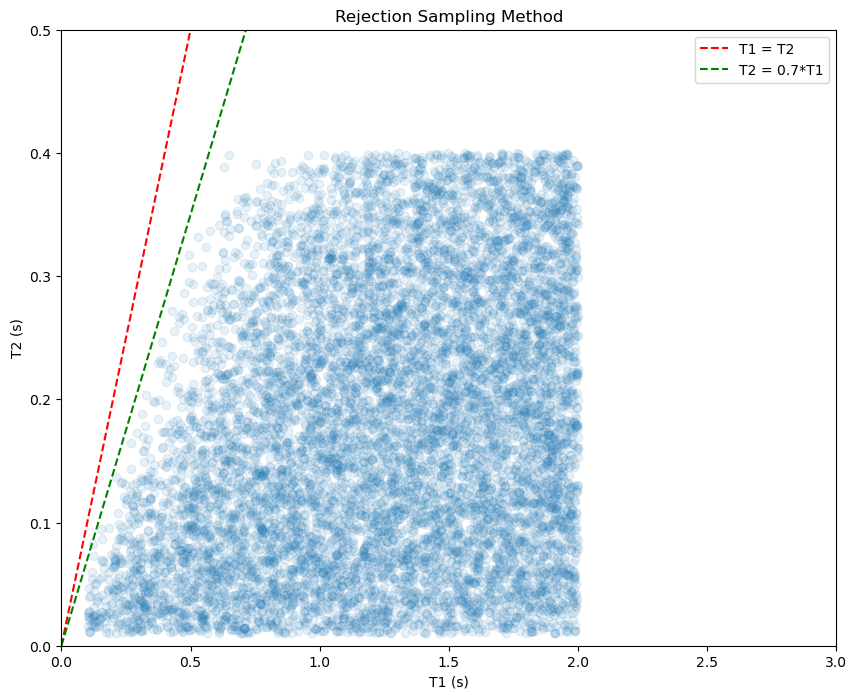

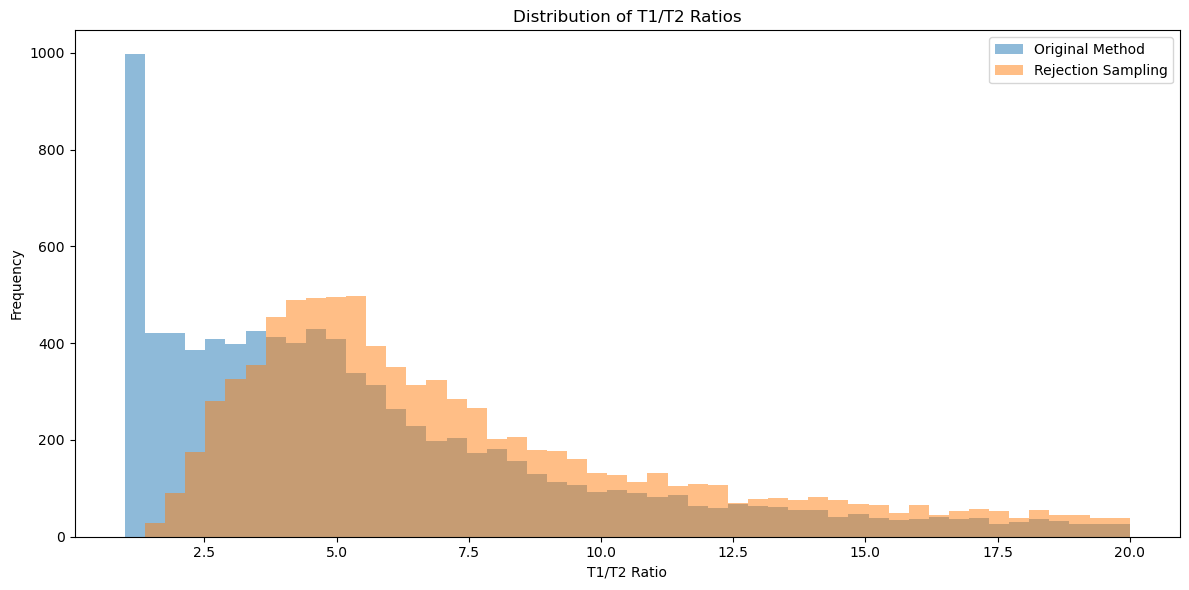

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def original_sample_t1_t2(num_samples):
    T1 = np.random.uniform(0.1, 2.0, num_samples)  # Range from 100ms to 3000ms
    T2 = np.random.uniform(0.01, 0.4, num_samples)  # Range from 10ms to 500ms
    T2 = np.minimum(T2, T1)
    return T1, T2

def rejection_sample_t1_t2(num_samples):
    T1_samples = []
    T2_samples = []
    
    while len(T1_samples) < num_samples:
        T1 = np.random.uniform(0.1, 2.0)
        T2 = np.random.uniform(0.01, 0.4)
        
        if T2 <= T1 and T2 <= 0.7 * T1:
            p = np.exp(-((T2/T1 - 0.1) / 0.3)**2)
            
            if np.random.random() < p:
                T1_samples.append(T1)
                T2_samples.append(T2)
    
    return np.array(T1_samples), np.array(T2_samples)

def plot_distribution(T1, T2, title):
    plt.figure(figsize=(10, 8))
    plt.scatter(T1, T2, alpha=0.1)
    plt.plot([0, 3], [0, 3], 'r--', label='T1 = T2')
    plt.plot([0, 3], [0, 0.7*3], 'g--', label='T2 = 0.7*T1')
    plt.xlabel('T1 (s)')
    plt.ylabel('T2 (s)')
    plt.title(title)
    plt.legend()
    plt.xlim(0, 3)
    plt.ylim(0, 0.5)

def print_statistics(T1, T2, method_name):
    print(f"\nStatistics for {method_name}:")
    print(f"T1 range: {T1.min():.3f} - {T1.max():.3f}")
    print(f"T2 range: {T2.min():.3f} - {T2.max():.3f}")
    print(f"Mean T1/T2 ratio: {np.mean(T1/T2):.3f}")
    print(f"Median T1/T2 ratio: {np.median(T1/T2):.3f}")
    print(f"Percentage of samples with T1/T2 < 1.43: {np.mean(T1/T2 < 1.43)*100:.2f}%")

# Generate samples
num_samples = 10000
T1_original, T2_original = original_sample_t1_t2(num_samples)
T1_rejection, T2_rejection = rejection_sample_t1_t2(num_samples)

# Plot distributions
plot_distribution(T1_original, T2_original, "Original Sampling Method")
plot_distribution(T1_rejection, T2_rejection, "Rejection Sampling Method")

# Print statistics
print_statistics(T1_original, T2_original, "Original Method")
print_statistics(T1_rejection, T2_rejection, "Rejection Sampling Method")

# Plot T1/T2 ratio histograms
plt.figure(figsize=(12, 6))
plt.hist(T1_original/T2_original, bins=50, range=(1, 20), alpha=0.5, label='Original Method')
plt.hist(T1_rejection/T2_rejection, bins=50, range=(1, 20), alpha=0.5, label='Rejection Sampling')
plt.xlabel('T1/T2 Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of T1/T2 Ratios')
plt.legend()

plt.tight_layout()
plt.show()

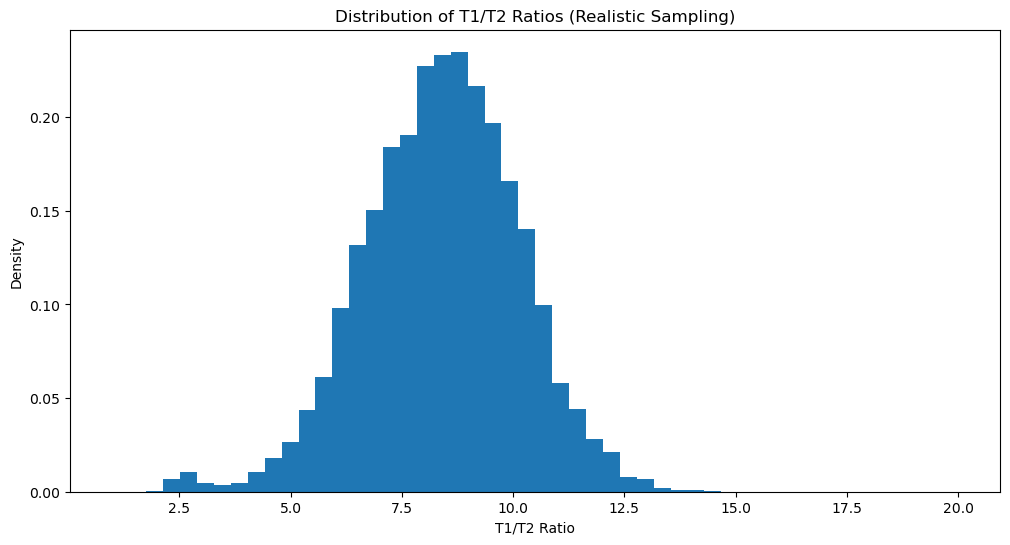

Mean T1/T2 ratio: 8.399
Median T1/T2 ratio: 8.465
Percentage of samples with T1/T2 < 3: 0.82%


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def realistic_t1_t2_sampling(num_samples):
    T1_samples = []
    T2_samples = []
    
    while len(T1_samples) < num_samples:
        T1 = np.random.uniform(0.4, 2.0)  # T1 range from 400ms to 2000ms
        T2 = np.random.uniform(0.04, 0.2)  # T2 range from 40ms to 200ms
        
        ratio = T1 / T2
        
        # Favor ratios between 5 and 12, with a peak around 8-9
        p = np.exp(-((ratio - 8.5) / 2.5)**2)
        
        # Add a small chance for lower ratios (e.g., CSF)
        if ratio < 3:
            p += 0.1
        
        if np.random.random() < p:
            T1_samples.append(T1)
            T2_samples.append(T2)
    
    return np.array(T1_samples), np.array(T2_samples)

# Generate samples
num_samples = 10000
T1, T2 = realistic_t1_t2_sampling(num_samples)

# Plot T1/T2 ratio histogram
plt.figure(figsize=(12, 6))
plt.hist(T1/T2, bins=50, range=(1, 20), density=True)
plt.xlabel('T1/T2 Ratio')
plt.ylabel('Density')
plt.title('Distribution of T1/T2 Ratios (Realistic Sampling)')
plt.show()

# Print statistics
print(f"Mean T1/T2 ratio: {np.mean(T1/T2):.3f}")
print(f"Median T1/T2 ratio: {np.median(T1/T2):.3f}")
print(f"Percentage of samples with T1/T2 < 3: {np.mean(T1/T2 < 3)*100:.2f}%")

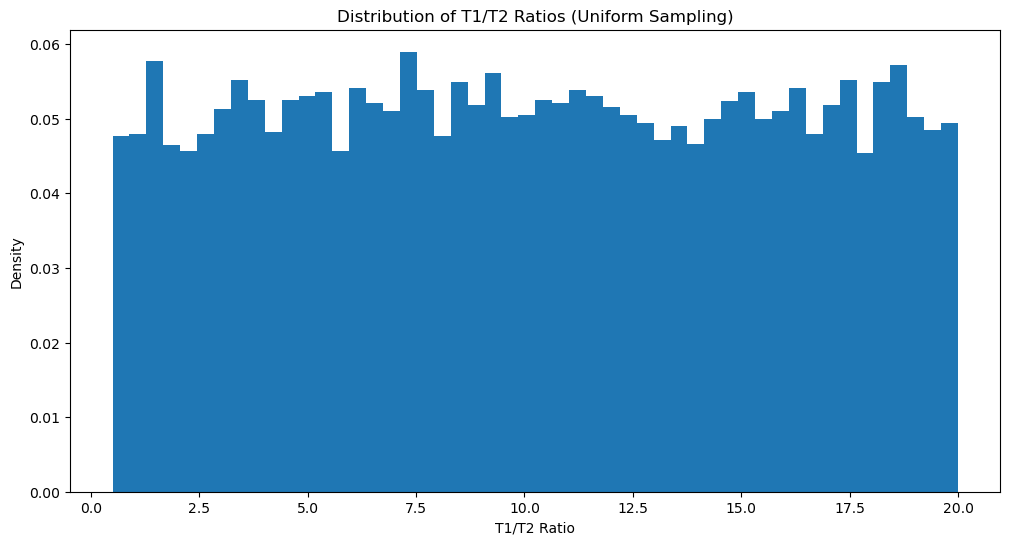

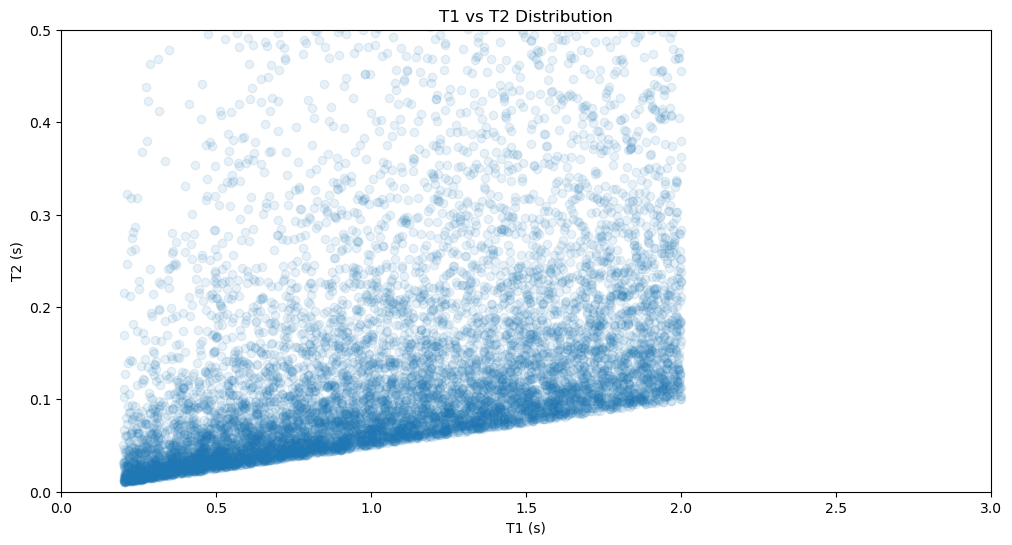

T1 range: 0.200 - 2.000
T2 range: 0.010 - 3.738
Mean T1/T2 ratio: 10.263
Median T1/T2 ratio: 10.214


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def uniform_t1t2_ratio_sampling(num_samples, ratio_min=0.5, ratio_max=20, t1_min=0.2, t1_max=2.0):
    # Generate uniform distribution of T1/T2 ratios
    ratios = np.random.uniform(ratio_min, ratio_max, num_samples)
    
    # Generate T1 values
    T1 = np.random.uniform(t1_min, t1_max, num_samples)
    
    # Calculate T2 values based on T1 and the ratio
    T2 = T1 / ratios
    
    return T1, T2, ratios

# Generate samples
num_samples = 10000
T1, T2, ratios = uniform_t1t2_ratio_sampling(num_samples)

# Plot T1/T2 ratio histogram
plt.figure(figsize=(12, 6))
plt.hist(ratios, bins=50, range=(0.5, 20), density=True)
plt.xlabel('T1/T2 Ratio')
plt.ylabel('Density')
plt.title('Distribution of T1/T2 Ratios (Uniform Sampling)')
plt.show()

# Plot T1 vs T2 scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(T1, T2, alpha=0.1)
plt.xlabel('T1 (s)')
plt.ylabel('T2 (s)')
plt.title('T1 vs T2 Distribution')
plt.xlim(0, 3)
plt.ylim(0, 0.5)
plt.show()

# Print statistics
print(f"T1 range: {T1.min():.3f} - {T1.max():.3f}")
print(f"T2 range: {T2.min():.3f} - {T2.max():.3f}")
print(f"Mean T1/T2 ratio: {np.mean(ratios):.3f}")
print(f"Median T1/T2 ratio: {np.median(ratios):.3f}")

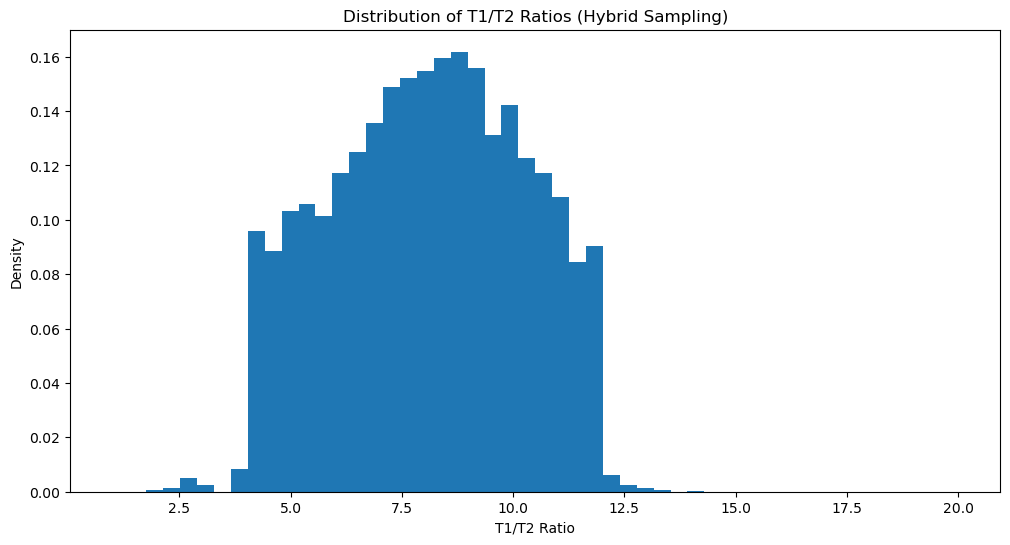

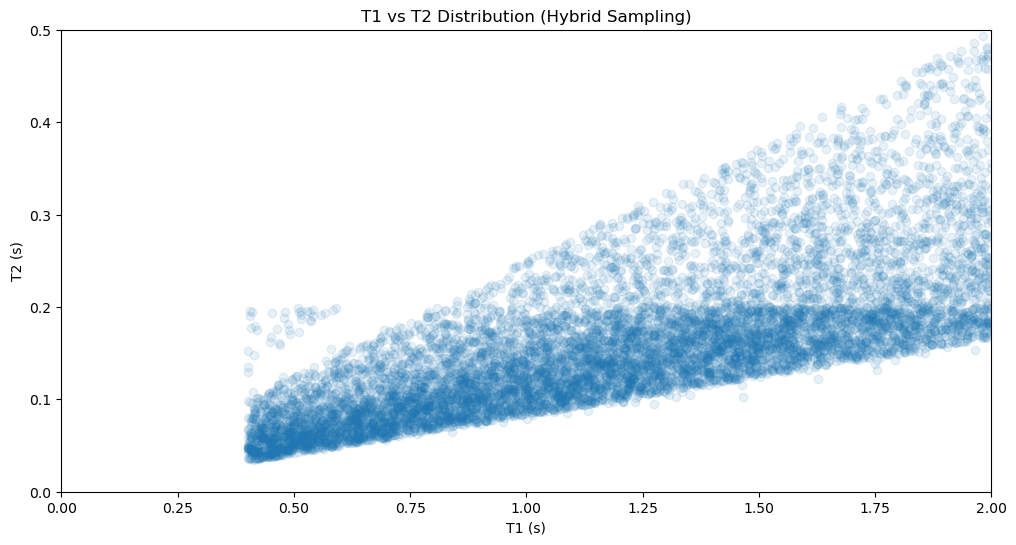

T1 range: 0.400 - 2.000
T2 range: 0.035 - 0.493
Mean T1/T2 ratio: 8.073
Median T1/T2 ratio: 8.145


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def uniform_t1t2_ratio_sampling(num_samples, ratio_min=4, ratio_max=12, t1_min=0.4, t1_max=2.0):
    ratios = np.random.uniform(ratio_min, ratio_max, num_samples)
    T1 = np.random.uniform(t1_min, t1_max, num_samples)
    T2 = T1 / ratios
    return T1, T2, ratios

def rejection_t1t2_sampling(num_samples):
    T1_samples, T2_samples = [], []
    while len(T1_samples) < num_samples:
        T1 = np.random.uniform(0.4, 2.0)
        T2 = np.random.uniform(0.04, 0.2)
        ratio = T1 / T2
        p = np.exp(-((ratio - 8.5) / 2.5)**2)
        if ratio < 3:
            p += 0.1
        if np.random.random() < p:
            T1_samples.append(T1)
            T2_samples.append(T2)
    return np.array(T1_samples), np.array(T2_samples)

def hybrid_t1t2_sampling(num_samples, uniform_ratio=0.7):
    num_uniform = int(num_samples * uniform_ratio)
    num_rejection = num_samples - num_uniform
    
    T1_uniform, T2_uniform, _ = uniform_t1t2_ratio_sampling(num_uniform)
    T1_rejection, T2_rejection = rejection_t1t2_sampling(num_rejection)
    
    T1 = np.concatenate([T1_uniform, T1_rejection])
    T2 = np.concatenate([T2_uniform, T2_rejection])
    
    # Shuffle the combined samples
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    
    return T1[indices], T2[indices]

# Generate samples using the hybrid method
num_samples = 10000
T1, T2 = hybrid_t1t2_sampling(num_samples)

# Plot T1/T2 ratio histogram
plt.figure(figsize=(12, 6))
plt.hist(T1/T2, bins=50, range=(1, 20), density=True)
plt.xlabel('T1/T2 Ratio')
plt.ylabel('Density')
plt.title('Distribution of T1/T2 Ratios (Hybrid Sampling)')
plt.show()

# Plot T1 vs T2 scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(T1, T2, alpha=0.1)
plt.xlabel('T1 (s)')
plt.ylabel('T2 (s)')
plt.title('T1 vs T2 Distribution (Hybrid Sampling)')
plt.xlim(0, 2)
plt.ylim(0, 0.5)
plt.show()

# Print statistics
print(f"T1 range: {T1.min():.3f} - {T1.max():.3f}")
print(f"T2 range: {T2.min():.3f} - {T2.max():.3f}")
print(f"Mean T1/T2 ratio: {np.mean(T1/T2):.3f}")
print(f"Median T1/T2 ratio: {np.median(T1/T2):.3f}")